In [51]:
import numpy as np
from sklearn.preprocessing import StandardScaler
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [52]:
X_b = np.c_[np.ones((100, 1)), X] # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [53]:
theta_best

array([[4.02212955],
       [2.78442692]])

In [54]:
X_new = np.array([[0], [2]])

In [55]:
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance

In [56]:
y_predict = X_new_b.dot(theta_best)

In [57]:
y_predict

array([[4.02212955],
       [9.59098338]])

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

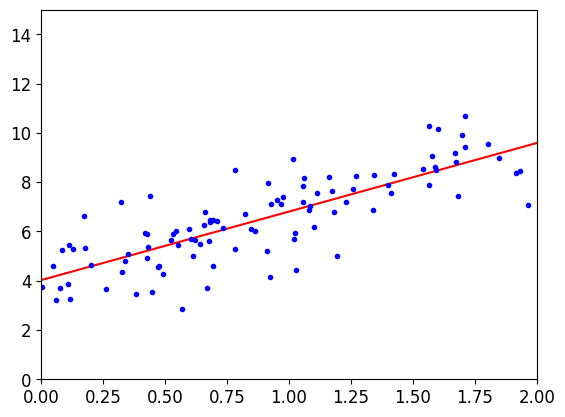

In [59]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
lin_reg = LinearRegression()

In [62]:
lin_reg.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
lin_reg.intercept_, lin_reg.coef_

(array([4.02212955]), array([[2.78442692]]))

In [64]:
lin_reg.predict(X_new)

array([[4.02212955],
       [9.59098338]])

In [65]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)

In [66]:
theta_best_svd

array([[4.02212955],
       [2.78442692]])

In [67]:
np.linalg.pinv(X_b).dot(y)

array([[4.02212955],
       [2.78442692]])

In [68]:
eta = 0.1 # learning rate
n_iterations = 1000
m = 100
theta = np.random.randn(2,1) # random initialization
for iteration in range(n_iterations):
 gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
 theta = theta - eta * gradients

In [69]:
theta

array([[4.02212955],
       [2.78442692]])

In [70]:
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2, 1)  # random initialization

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

print(theta)

[[4.03123525]
 [2.79123122]]


In [71]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [72]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.96833857]), array([2.73429098]))

In [73]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [74]:
from sklearn.preprocessing import PolynomialFeatures

In [75]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

In [76]:
X_poly = poly_features.fit_transform(X)

In [77]:
X[0]

array([-0.60253549])

In [78]:
X_poly[0]

array([-0.60253549,  0.36304902])

In [79]:
lin_reg = LinearRegression()

In [80]:
lin_reg.fit(X_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [81]:
lin_reg.intercept_, lin_reg.coef_

(array([2.03406066]), array([[1.0271742 , 0.52169532]]))

In [82]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.legend()

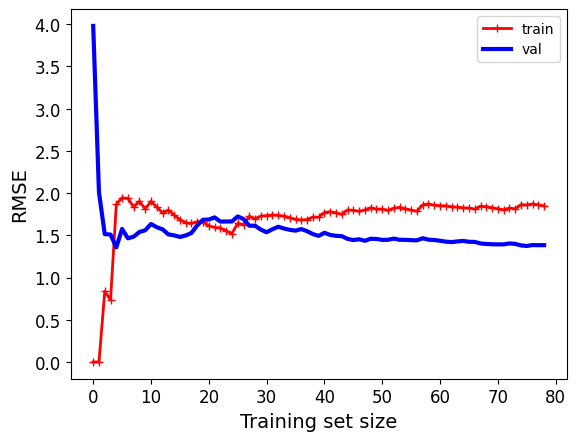

In [83]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

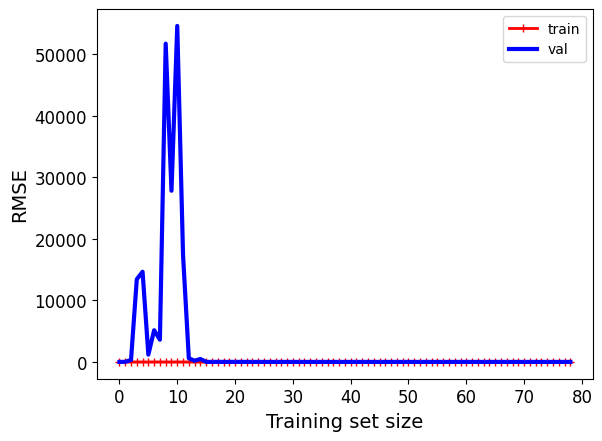

In [84]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
 ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
 ("lin_reg", LinearRegression()),
 ])
plot_learning_curves(polynomial_regression, X, y)

In [85]:
from sklearn.linear_model import Ridge

In [86]:
ridge_reg = Ridge(alpha=1, solver="cholesky")

In [87]:
ridge_reg.fit(X, y)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'cholesky'
,positive,False
,random_state,None


In [88]:
ridge_reg.predict([[1.5]])

array([5.1444598])

In [89]:
sgd_reg = SGDRegressor(penalty="l2")

In [90]:
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [91]:
sgd_reg.predict([[1.5]])

array([5.13640233])

In [92]:
from sklearn.linear_model import Lasso

In [93]:
lasso_reg = Lasso(alpha=0.1)

In [94]:
lasso_reg.fit(X, y)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [95]:
lasso_reg.predict([[1.5]])

array([5.10105816])

In [96]:
from sklearn.linear_model import ElasticNet

In [97]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [98]:
elastic_net.fit(X, y)

,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [99]:
elastic_net.predict([[1.5]])

array([5.10080696])

In [100]:
from sklearn.model_selection import train_test_split

# X = input features
# y = target values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [101]:
from sklearn import datasets

In [102]:
iris = datasets.load_iris()

In [103]:
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [104]:
X = iris["data"][:, 3:] # petal width

In [108]:
y = (iris["target"] == 2).astype(int)  # 1 if Iris virginica, else 0
y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [109]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


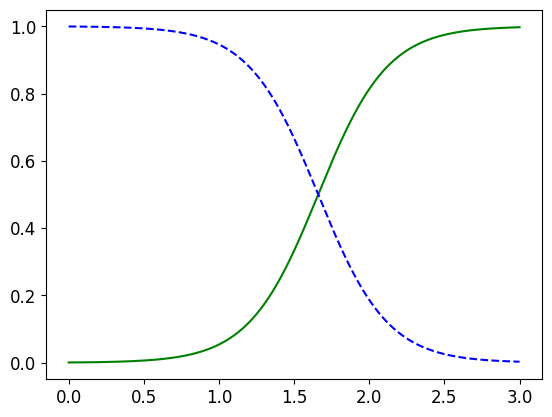

In [110]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris virginica")
# + more Matplotlib code to make the image look pretty

In [111]:
log_reg.predict([[1.7], [1.5]])

array([1, 0])

In [112]:
X = iris["data"][:, (2, 3)] # petal length, petal width
y = iris["target"]
softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs", C=10)
softmax_reg.fit(X, y)

c:\Users\one\anaconda3\envs\tf_project\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [113]:
softmax_reg.predict([[5, 2]])

array([2])

In [114]:
softmax_reg.predict_proba([[5, 2]])

array([[6.21626373e-07, 5.73689802e-02, 9.42630398e-01]])